# Phishing Email Detection (Rule-Based Approach)

This notebook analyzes a dataset of emails with the goal of identifying clear patterns that distinguish phishing attempts from legitimate messages.

The process begins with exploratory data analysis (EDA), where the dataset’s structure, feature distributions, and class balance are examined in detail. This step provides a solid understanding of the data and highlights potential challenges, such as class imbalance.

Building on these insights, the notebook develops and evaluates rule-based methods for phishing detection. These approaches emphasize interpretability and provide a practical baseline for distinguishing between malicious and non-malicious emails.

# Environment Setup

In [44]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [45]:
df = pd.read_csv(r"/content/phishing_emails.csv", index_col=[0])

In [46]:
print(f"Dataset loaded successfully with {df.shape[0]} rows and {df.shape[1]} columns.")

Dataset loaded successfully with 13898 rows and 9 columns.


In [47]:
df.head()

,num_words,num_unique_words,num_stopwords,num_links,num_unique_domains,num_email_addresses,num_spelling_errors,num_urgent_keywords,label
506799,102,75,39,2,2,0,4,0,1
506800,63,59,3,0,0,0,0,0,1
506803,1091,551,323,0,0,0,57,2,1
506804,91,74,32,0,0,0,5,1,1
506806,242,157,72,0,0,0,6,0,1


# Exploratory Data Analysis (EDA)

Before creating detection rules, it’s important to understand the dataset. This step builds context and highlights challenges that may shape later work. The analysis includes:

* Checking the dataset’s dimensions to see its scale

* Summarizing features to understand their role and relevance

* Reviewing class distribution to identify imbalances between phishing and non-phishing emails

* Verifying feature data types for compatibility with downstream methods

In [48]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")

Rows: 13898, Columns: 9


In [49]:
df.describe(include="all").T.head(10)

,count,mean,std,min,25%,50%,75%,max
num_words,13898.0,258.560296,636.566629,1.0,54.0,115.0,255.0,27270.0
num_unique_words,13898.0,125.697151,162.202303,1.0,44.0,80.0,146.0,4360.0
num_stopwords,13898.0,76.957188,203.703458,0.0,12.0,31.0,74.0,8521.0
num_links,13898.0,0.668010,3.982261,0.0,0.0,0.0,0.0,143.0
num_unique_domains,13898.0,0.330767,1.377678,0.0,0.0,0.0,0.0,84.0
num_email_addresses,13898.0,1.117139,8.201619,0.0,0.0,0.0,0.0,447.0
num_spelling_errors,13898.0,21.469132,56.323198,0.0,3.0,8.0,19.0,1977.0
num_urgent_keywords,13898.0,0.288675,0.626456,0.0,0.0,0.0,0.0,6.0
label,13898.0,0.500000,0.500018,0.0,0.0,0.5,1.0,1.0


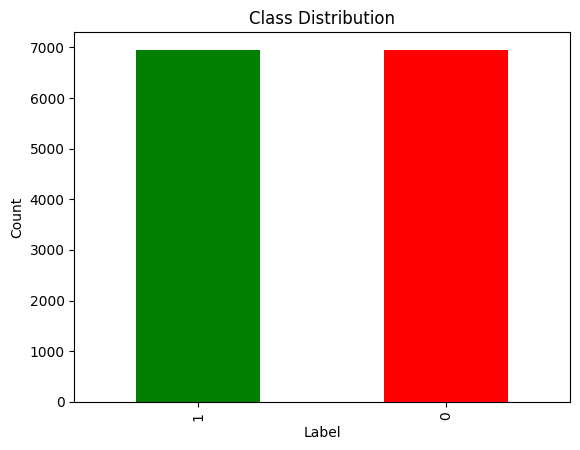

In [50]:
df['label'].value_counts().plot(kind='bar', color=['green', 'red'])
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

In [51]:
df.dtypes

,0
num_words,int64
num_unique_words,int64
num_stopwords,int64
num_links,int64
num_unique_domains,int64
num_email_addresses,int64
num_spelling_errors,int64
num_urgent_keywords,int64
label,int64


# Analysis of Variance (ANOVA)

To evaluate which features provide meaningful separation between phishing and legitimate emails, an Analysis of Variance (ANOVA) test is applied. This method highlights the numerical features that contribute most strongly to class differentiation.

The workflow proceeds as follows:

* Feature grouping : Separate the dataset into binary and numerical feature subsets.

* Statistical testing : Apply ANOVA (f_classif) to the numerical features to measure their ability to explain variance between the two classes.

* Feature ranking : Order the numerical features by statistical significance, using p-values as the ranking criterion.

This analysis offers an early indication of which variables are likely to carry predictive power and can inform both rule-based and model-driven approaches later in the pipeline.

In [52]:
binary_features = [col for col in df.columns if df[col].dropna().value_counts().index.isin([0,1]).all()]
numerical_features = [col for col in df.columns if col not in binary_features + ['label']]

print("Binary features (count):", len(binary_features))
print("Binary features:", binary_features)

print("Numerical features (count):", len(numerical_features))
print("Numerical features:", numerical_features)



Binary features (count): 1
Binary features: ['label']
Numerical features (count): 8
Numerical features: ['num_words', 'num_unique_words', 'num_stopwords', 'num_links', 'num_unique_domains', 'num_email_addresses', 'num_spelling_errors', 'num_urgent_keywords']


/tmp/ipython-input-2417299632.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


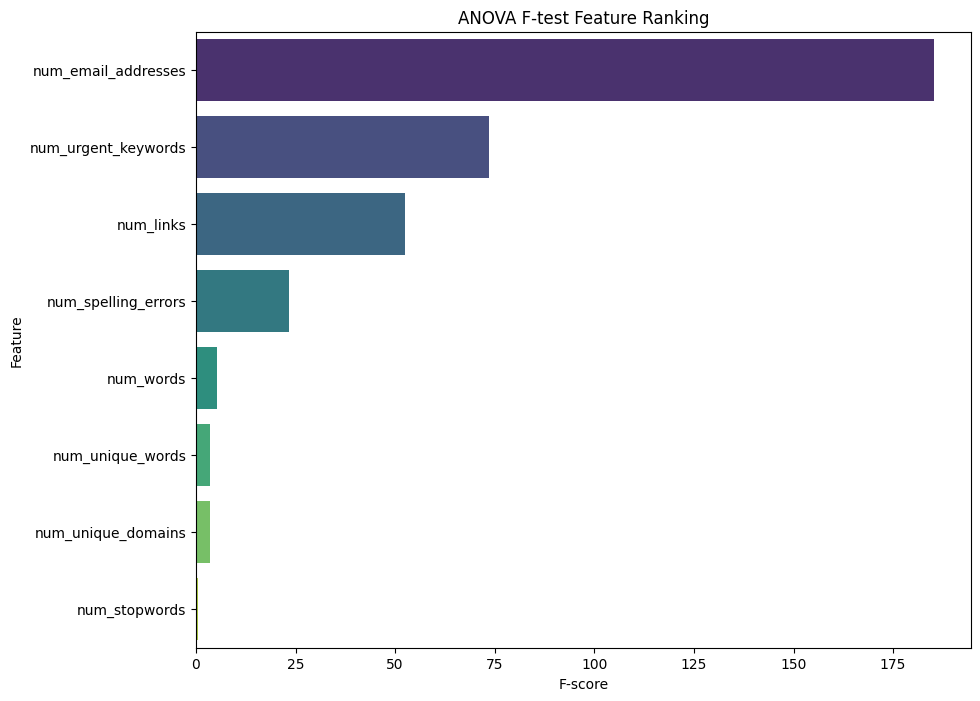

In [53]:
from sklearn.feature_selection import SelectKBest, f_classif

X = df[numerical_features].fillna(0)
y = df['label']

fs = SelectKBest(score_func=f_classif, k='all')
fs.fit(X, y)

scores = pd.DataFrame({
    'feature': numerical_features,
    'f_score': fs.scores_,
    'p_value': fs.pvalues_
}).sort_values('f_score', ascending=False)

plt.figure(figsize=(10,8))
sns.barplot(
    data=scores,
    x="f_score",
    y="feature",
    palette="viridis"
)
plt.title("ANOVA F-test Feature Ranking")
plt.xlabel("F-score")
plt.ylabel("Feature")
plt.show()


In [54]:
pvalues = pd.DataFrame({
    'feature': numerical_features,
    'p_value': fs.pvalues_
}).sort_values('p_value')

print("Top 5 features by ANOVA p-value:")
display(pvalues.head(5))


Top 5 features by ANOVA p-value:


,feature,p_value
5,num_email_addresses,6.387202e-42
7,num_urgent_keywords,1.049221e-17
3,num_links,4.481729e-13
6,num_spelling_errors,1.356192e-06
0,num_words,2.154711e-02


Using an ANOVA test, we ranked numerical features by statistical significance (lowest p-values) to identify the strongest predictors of phishing emails. The top five features selected form the basis of our rule-based detection system:

* num_email_addresses: Number of email addresses found in the email body.

* num_urgent_keywords: Count of urgency-related words (e.g., “urgent,” “verify,” “update”).

* num_links: Number of hyperlinks contained in the email.

* num_spelling_errors: Count of misspelled words in the email content.

* num_words: Total number of words in the email body.

These features capture structural, linguistic, and behavioral signals commonly associated with phishing attempts. By focusing on these high-impact indicators, the rule-based detection system is designed to flag suspicious messages with greater precision.

#Rule-Based Detection Framework

From the ANOVA analysis, we identified five numerical features (plus one binary feature, Redirect) that are statistically significant for distinguishing phishing from legitimate websites.

In this section, we will design simple rule-based detectors using these features. The workflow will be as follows:

* Feature exploration: Examine the distribution of each selected feature across phishing vs. legitimate classes.

* Threshold sweep: Systematically test different threshold values for each feature to evaluate separation power.

* Greedy best-threshold check: Select the threshold that maximizes classification accuracy for each feature individually.

* Accuracy evaluation: Apply the derived rules to the dataset and measure accuracy, using the balanced dataset so that 50% represents random guessing.

* Conclusion: Summarize the performance of rule-based classification and set the stage for comparing against machine learning models.

## Rule A: num_email_addresses

### Feature Exploration

In [55]:
df.num_email_addresses.fillna("NONE").unique()

array([  0,   1,   3,   2,   6,   4,  27,   8,   5,  14,  26,  12,  20,
         7,  24,  43,  15,  17,  75,  13,  36,  28,  21,  16,  11,   9,
        39,  25,  10,  58,  64,  19,  18,  23, 100,  33,  30,  22,  38,
        79,  49,  32,  61,  35,  31,  53,  63,  51,  59,  77,  29,  91,
        90, 204,  40,  78,  80, 216,  71, 107, 183,  52,  41,  48,  65,
        82,  34, 127,  57, 217, 103,  54,  95,  37,  47, 447, 387, 102,
       276,  76,  68])

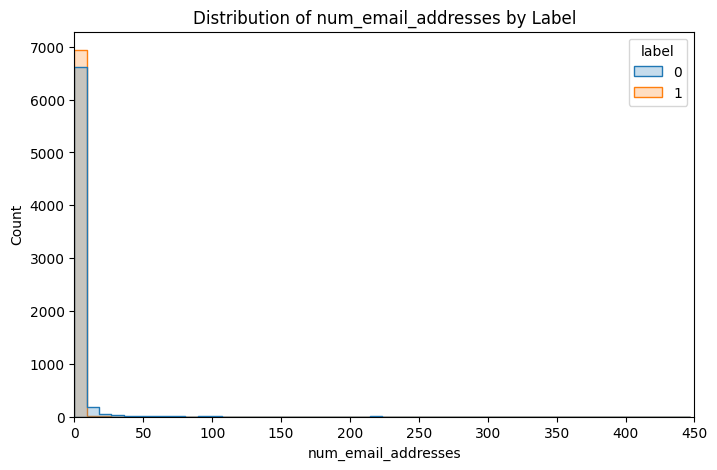

In [56]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="num_email_addresses", hue="label", bins=50, kde=False, element="step")
plt.xlim(0,450)
plt.title("Distribution of num_email_addresses by Label")
plt.show()


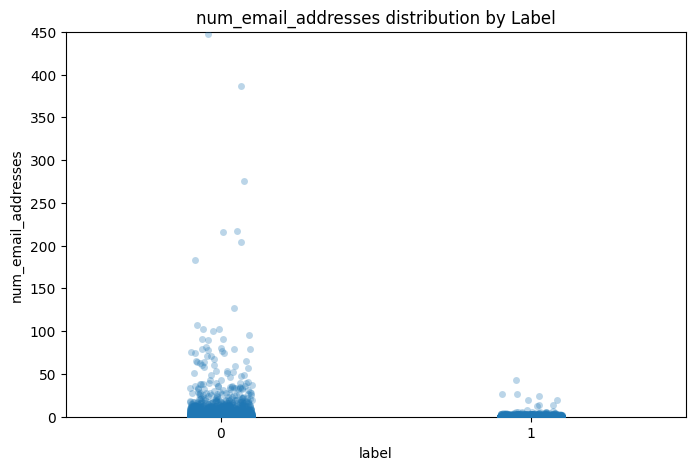

In [57]:
plt.figure(figsize=(8,5))
sns.stripplot(x="label", y="num_email_addresses", data=df, jitter=True, alpha=0.3)
plt.ylim(0,450)
plt.title("num_email_addresses distribution by Label")
plt.show()


### Threshold Sweep


To convert this feature into a simple rule, we test different thresholds.  
For each possible value of num_email_addresses we check two possible rules:

- Classify as phishing if < v
- Classify as phishing if >= v

We record the accuracy for each threshold and direction, then plot the results.


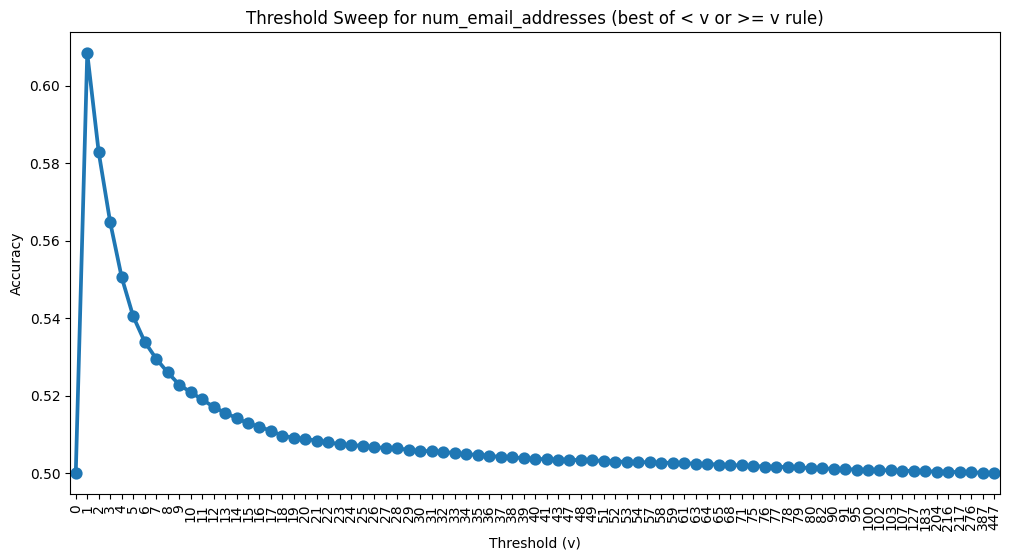

In [58]:
possible_values = sorted(df.num_email_addresses.dropna().unique())

accuracies_num_email_addresses = []

for v in possible_values:
    tmp_rule_less = (df.num_email_addresses < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_email_addresses >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    best_acc = max(acc_less, acc_greater)
    accuracies_num_email_addresses.append((v, best_acc))

plt.figure(figsize=(12,6))
sns.pointplot(x=[c[0] for c in accuracies_num_email_addresses],
              y=[c[1] for c in accuracies_num_email_addresses])
plt.xticks(rotation=90)
plt.title("Threshold Sweep for num_email_addresses (best of < v or >= v rule)")
plt.xlabel("Threshold (v)")
plt.ylabel("Accuracy")
plt.show()


### Greedy Threshold Value Check


Next, we identify the best single threshold that maximizes accuracy.  
This tells us both the value of num_email_addresses that works best and the
direction of the inequality (< or >=).


In [59]:
possible_values = sorted(df.num_email_addresses.dropna().unique())

best_threshold = None
best_accuracy = 0
best_direction = None

for v in possible_values:
    tmp_rule_less = (df.num_email_addresses < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_email_addresses >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    if acc_less > best_accuracy:
        best_accuracy = acc_less
        best_threshold = v
        best_direction = "<"

    if acc_greater > best_accuracy:
        best_accuracy = acc_greater
        best_threshold = v
        best_direction = ">="

print(f"Best threshold value: {best_threshold}, Direction: {best_direction}, Accuracy: {best_accuracy:.4f}")


Best threshold value: 1, Direction: <, Accuracy: 0.6084


### Accuracy Test


Finally, we implement the chosen threshold rule in the dataset and measure its
accuracy against the ground-truth labels.


In [60]:
df["rule_a"] = (df.num_email_addresses < 1).astype(int)

rule_a_accuracy = (df["rule_a"] == df["label"]).mean()
print(rule_a_accuracy)


0.6084328680385667


## Rule B: num_urgent_keywords

### Feature Exploration

In [61]:
df.num_urgent_keywords.fillna("NONE").unique()

array([0, 2, 1, 3, 4, 5, 6])

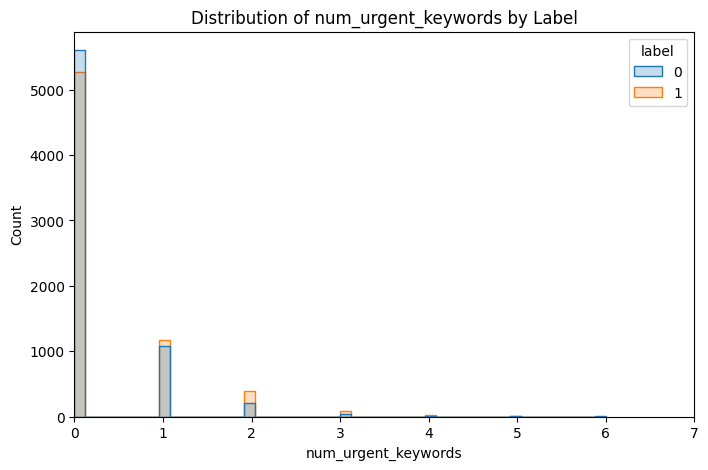

In [62]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="num_urgent_keywords", hue="label", bins=50, kde=False, element="step")
plt.xlim(0,7)
plt.title("Distribution of num_urgent_keywords by Label")
plt.show()


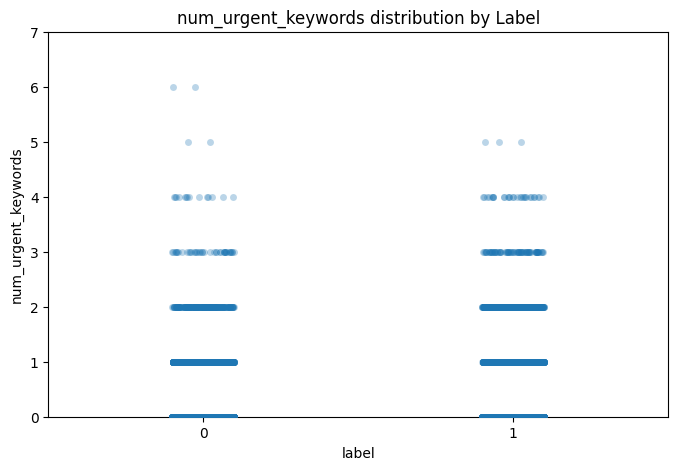

In [63]:
plt.figure(figsize=(8,5))
sns.stripplot(x="label", y="num_urgent_keywords", data=df, jitter=True, alpha=0.3)
plt.ylim(0,7)
plt.title("num_urgent_keywords distribution by Label")
plt.show()


### Threshold Sweep

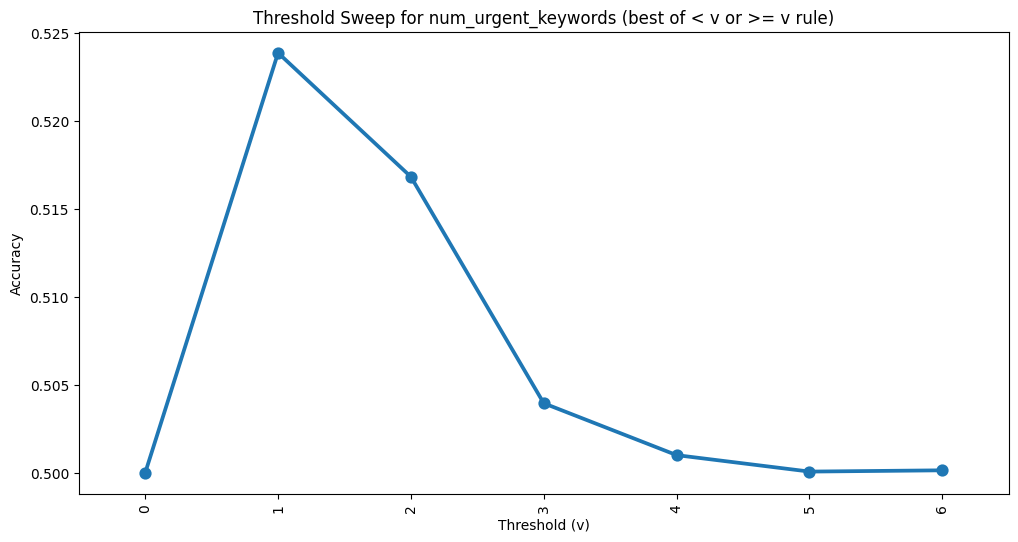

In [64]:
possible_values = sorted(df.num_urgent_keywords.dropna().unique())

accuracies_num_urgent_keywords = []

for v in possible_values:
    tmp_rule_less = (df.num_urgent_keywords < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_urgent_keywords >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    best_acc = max(acc_less, acc_greater)
    accuracies_num_urgent_keywords.append((v, best_acc))

plt.figure(figsize=(12,6))
sns.pointplot(x=[c[0] for c in accuracies_num_urgent_keywords],
              y=[c[1] for c in accuracies_num_urgent_keywords])
plt.xticks(rotation=90)
plt.title("Threshold Sweep for num_urgent_keywords (best of < v or >= v rule)")
plt.xlabel("Threshold (v)")
plt.ylabel("Accuracy")
plt.show()


### Greedy Threshold Value Check

In [65]:
possible_values = sorted(df.num_urgent_keywords.dropna().unique())

best_threshold = None
best_accuracy = 0
best_direction = None

for v in possible_values:
    tmp_rule_less = (df.num_urgent_keywords < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_urgent_keywords >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    if acc_less > best_accuracy:
        best_accuracy = acc_less
        best_threshold = v
        best_direction = "<"

    if acc_greater > best_accuracy:
        best_accuracy = acc_greater
        best_threshold = v
        best_direction = ">="

print(f"Best threshold value: {best_threshold}, Direction: {best_direction}, Accuracy: {best_accuracy:.4f}")


Best threshold value: 1, Direction: >=, Accuracy: 0.5239


### Accuracy Test

In [66]:
df["rule_b"] = (df.num_urgent_keywords >= 1).astype(int)

rule_b_accuracy = (df["rule_b"] == df["label"]).mean()
print(rule_b_accuracy)


0.523888329256008


## Rule C: num_links

### Feature Exploration

In [67]:
df.num_links.fillna("NONE").unique()

array([  2,   0,   1,   4,   3,   5,   6,  16,   7,  65,  19,   8,  13,
        14,  59,  57,  11,   9,  12,  10,  51,  72,  75,  44,  40,  42,
        37,  87,  32,  31,  33,  28,  22,  45,  15,  76, 121,  20,  21,
        25,  43,  55,  26,  36,  24,  27,  17,  58,  35,  46, 128,  30,
        29, 143,  34,  39,  48,  96,  38,  88,  18,  60])

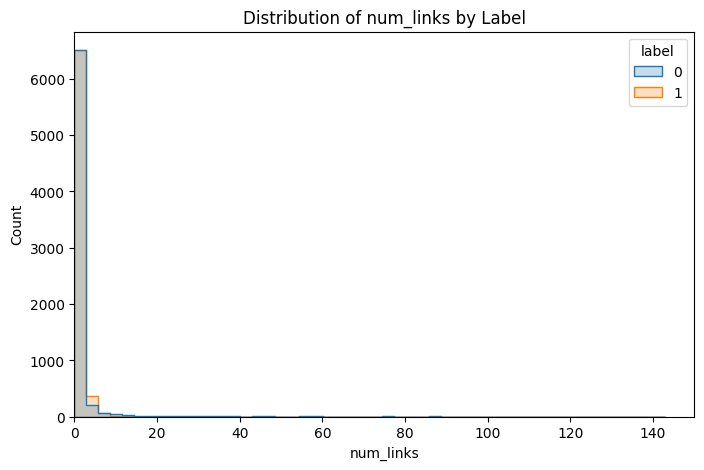

In [68]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="num_links", hue="label", bins=50, kde=False, element="step")
plt.xlim(0,150)
plt.title("Distribution of num_links by Label")
plt.show()


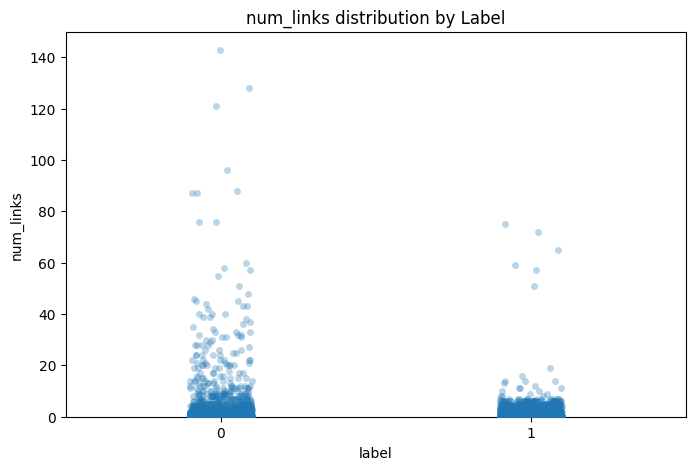

In [69]:
plt.figure(figsize=(8,5))
sns.stripplot(x="label", y="num_links", data=df, jitter=True, alpha=0.3)
plt.ylim(0,150)
plt.title("num_links distribution by Label")
plt.show()


### Threshold Sweep

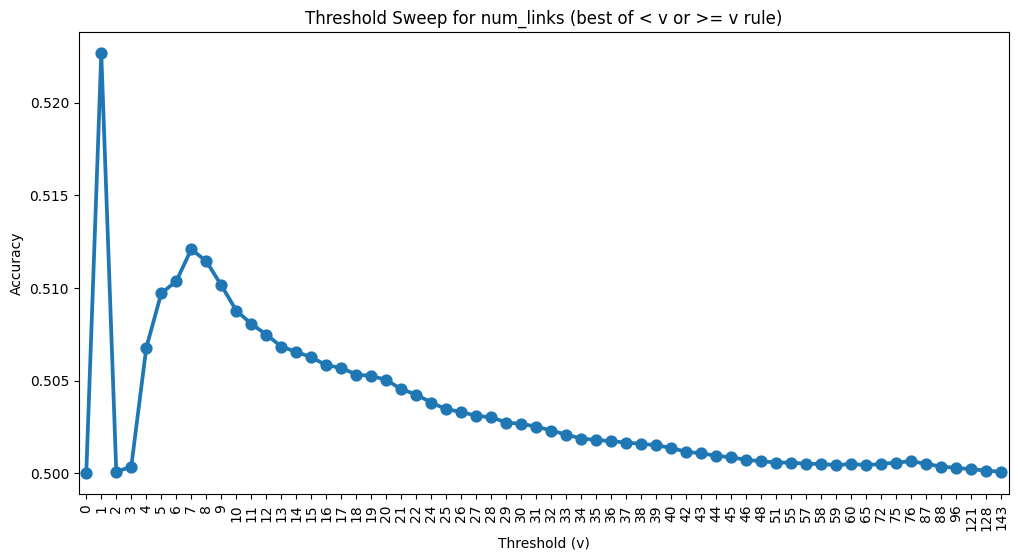

In [70]:
possible_values = sorted(df.num_links.dropna().unique())

accuracies_num_links = []

for v in possible_values:
    tmp_rule_less = (df.num_links < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_links >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    best_acc = max(acc_less, acc_greater)
    accuracies_num_links.append((v, best_acc))

plt.figure(figsize=(12,6))
sns.pointplot(x=[c[0] for c in accuracies_num_links],
              y=[c[1] for c in accuracies_num_links])
plt.xticks(rotation=90)
plt.title("Threshold Sweep for num_links (best of < v or >= v rule)")
plt.xlabel("Threshold (v)")
plt.ylabel("Accuracy")
plt.show()


### Greedy Threshold Value Check

In [71]:
possible_values = sorted(df.num_links.dropna().unique())

best_threshold = None
best_accuracy = 0
best_direction = None

for v in possible_values:
    tmp_rule_less = (df.num_links < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_links >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    if acc_less > best_accuracy:
        best_accuracy = acc_less
        best_threshold = v
        best_direction = "<"

    if acc_greater > best_accuracy:
        best_accuracy = acc_greater
        best_threshold = v
        best_direction = ">="

print(f"Best threshold value: {best_threshold}, Direction: {best_direction}, Accuracy: {best_accuracy:.4f}")


Best threshold value: 1, Direction: <, Accuracy: 0.5227


### Accuracy Test

In [72]:
df["rule_c"] = (df.num_links < 1).astype(int)

rule_c_accuracy = (df["rule_c"] == df["label"]).mean()
print(rule_c_accuracy)


0.522665131673622


## Rule D: num_spelling_errors

### Feature Exploration

In [73]:
df.num_spelling_errors.fillna("NONE").unique()

array([   4,    0,   57,    5,    6,    2,   12,    8,   16,    1,    3,
         59,   14,    7,   17,   95,   23,   15,   53,   11,   37,    9,
         58,   54,   13,   39,   26,   21,   28,  243,   10,   41,   62,
         20,   48,   18,   67,  123,  157,  106,  150,   61,  147,  138,
         40,  139,   24,   19,   85,   56,   44,   34,  211,   27,   30,
        382,  202,   29,  561,   77,  145,  223,   31,  209,   33,   65,
        101,   38,  168,   22,   68,   63,   97,  195,   32,  121,   70,
        102,   25,   50,   35,  222,   74,  131,   60,   43,  242,  128,
        134,  280,   46,   75,   89,   36,  370,   91,   42,  119,   84,
         94,   47,  152,   79,   73,   64,   93,  198,   49,  342,   45,
        535,   83,  151,  292,   88,   51,  125,  156,  115,  601,  225,
         71,   72,   66,   98,  120,  231,  122,   76,  127,  677,  191,
        142,  132,  104,  322,  205,  112,  153,   82,  135,  154,  146,
        300,   78,  520,   90,  113,  377,  340,  3

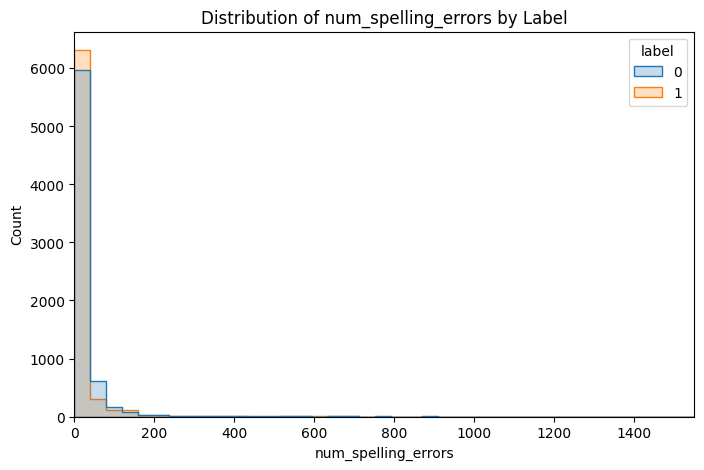

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="num_spelling_errors", hue="label", bins=50, kde=False, element="step")
plt.xlim(0,1550)
plt.title("Distribution of num_spelling_errors by Label")
plt.show()


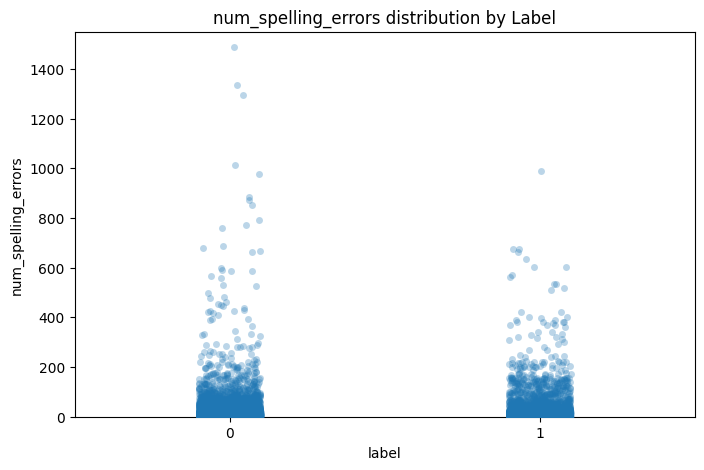

In [75]:
plt.figure(figsize=(8,5))
sns.stripplot(x="label", y="num_spelling_errors", data=df, jitter=True, alpha=0.3)
plt.ylim(0,1550)
plt.title("num_spelling_errors distribution by Label")
plt.show()


### Threshold Sweep

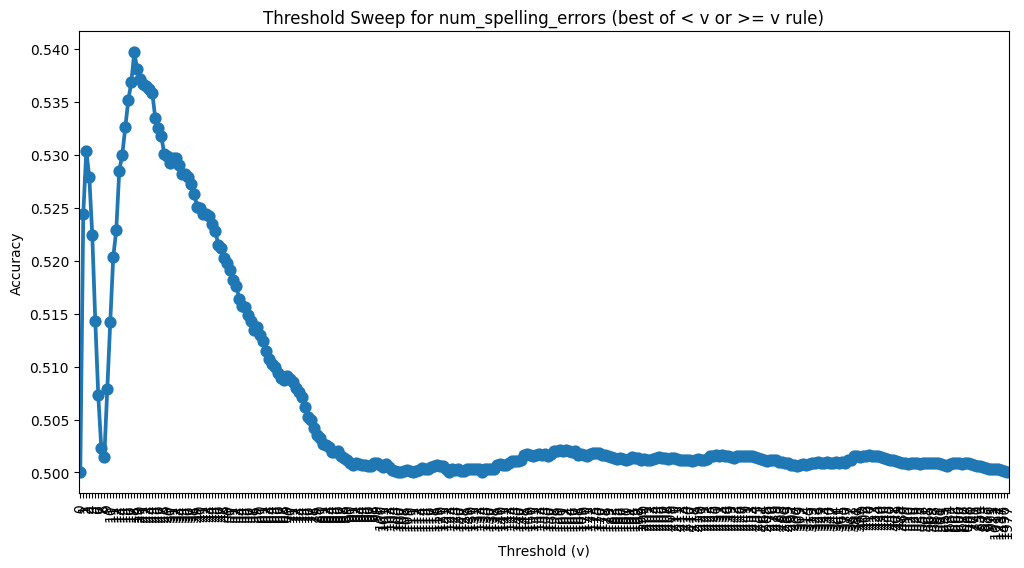

In [76]:
possible_values = sorted(df.num_spelling_errors.dropna().unique())

accuracies_num_spelling_errors = []

for v in possible_values:
    tmp_rule_less = (df.num_spelling_errors < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_spelling_errors >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    best_acc = max(acc_less, acc_greater)
    accuracies_num_spelling_errors.append((v, best_acc))

plt.figure(figsize=(12,6))
sns.pointplot(x=[c[0] for c in accuracies_num_spelling_errors],
              y=[c[1] for c in accuracies_num_spelling_errors])
plt.xticks(rotation=90)
plt.title("Threshold Sweep for num_spelling_errors (best of < v or >= v rule)")
plt.xlabel("Threshold (v)")
plt.ylabel("Accuracy")
plt.show()


### Greedy Threshold Value Check

In [77]:
possible_values = sorted(df.num_spelling_errors.dropna().unique())

best_threshold = None
best_accuracy = 0
best_direction = None

for v in possible_values:
    tmp_rule_less = (df.num_spelling_errors < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_spelling_errors >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    if acc_less > best_accuracy:
        best_accuracy = acc_less
        best_threshold = v
        best_direction = "<"

    if acc_greater > best_accuracy:
        best_accuracy = acc_greater
        best_threshold = v
        best_direction = ">="

print(f"Best threshold value: {best_threshold}, Direction: {best_direction}, Accuracy: {best_accuracy:.4f}")


Best threshold value: 18, Direction: <, Accuracy: 0.5396


### Accuracy Test

In [78]:
df["rule_d"] = (df.num_spelling_errors < 18).astype(int)

rule_d_accuracy = (df["rule_d"] == df["label"]).mean()
print(rule_d_accuracy)


0.5396459922290977


## Rule E: num_words

### Feature Exploration

In [79]:
df.num_words.fillna("NONE").unique()

array([ 102,   63, 1091, ..., 1190,  750, 1248])

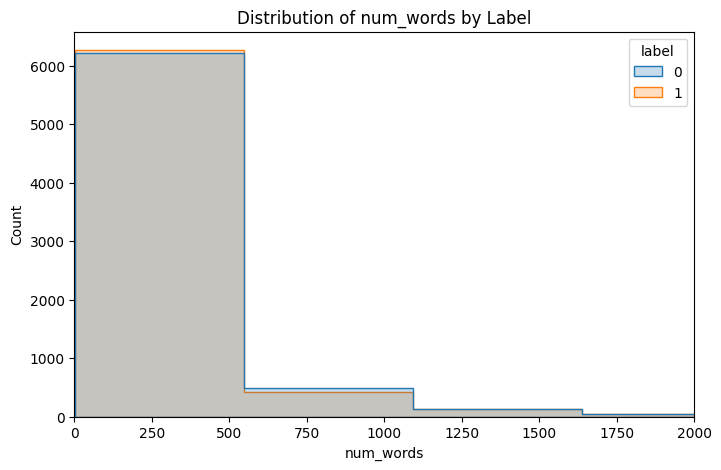

In [80]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="num_words", hue="label", bins=50, kde=False, element="step")
plt.xlim(0,2000)
plt.title("Distribution of num_words by Label")
plt.show()


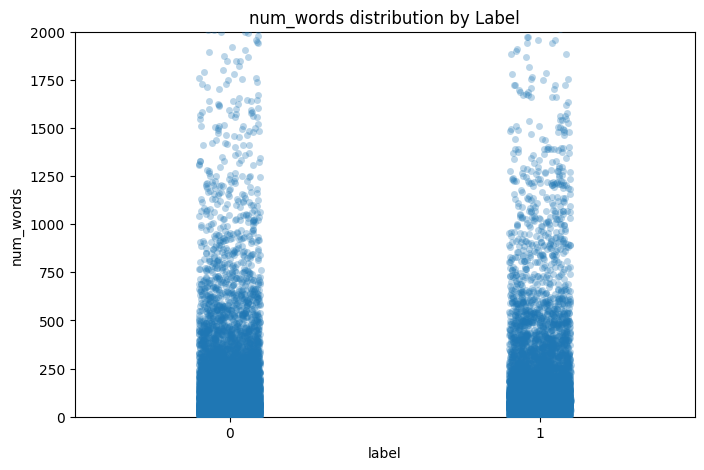

In [81]:
plt.figure(figsize=(8,5))
sns.stripplot(x="label", y="num_words", data=df, jitter=True, alpha=0.3)
plt.ylim(0,2000)
plt.title("num_words distribution by Label")
plt.show()


### Threshold Sweep

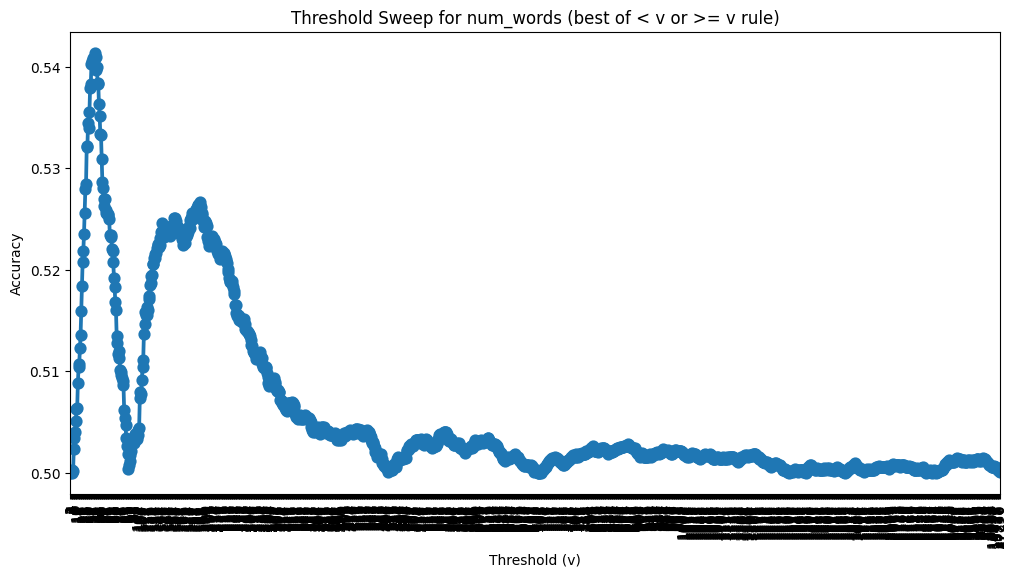

In [82]:
possible_values = sorted(df.num_words.dropna().unique())

accuracies_num_words = []

for v in possible_values:
    tmp_rule_less = (df.num_words < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_words >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    best_acc = max(acc_less, acc_greater)
    accuracies_num_words.append((v, best_acc))

plt.figure(figsize=(12,6))
sns.pointplot(x=[c[0] for c in accuracies_num_words],
              y=[c[1] for c in accuracies_num_words])
plt.xticks(rotation=90)
plt.title("Threshold Sweep for num_words (best of < v or >= v rule)")
plt.xlabel("Threshold (v)")
plt.ylabel("Accuracy")
plt.show()


### Greedy Threshold Value Check

In [83]:
possible_values = sorted(df.num_words.dropna().unique())

best_threshold = None
best_accuracy = 0
best_direction = None

for v in possible_values:
    tmp_rule_less = (df.num_words < v).astype(int)
    acc_less = (tmp_rule_less == df["label"]).mean()

    tmp_rule_greater = (df.num_words >= v).astype(int)
    acc_greater = (tmp_rule_greater == df["label"]).mean()

    if acc_less > best_accuracy:
        best_accuracy = acc_less
        best_threshold = v
        best_direction = "<"

    if acc_greater > best_accuracy:
        best_accuracy = acc_greater
        best_threshold = v
        best_direction = ">="

print(f"Best threshold value: {best_threshold}, Direction: {best_direction}, Accuracy: {best_accuracy:.4f}")


Best threshold value: 37, Direction: >=, Accuracy: 0.5414


### Accuracy Test

In [84]:
df["rule_e"] = (df.num_words >= 37).astype(int)

rule_e_accuracy = (df["rule_e"] == df["label"]).mean()
print(rule_e_accuracy)


0.5413728594042309


# Rule Combination


Now that we have defined five individual rules, we combine them into ensemble
decision strategies:

1. **OR Rule** → If any of the rules (A–E) fire, classify as phishing.  
   - Very sensitive, but may produce false positives.  

2. **AND Rule** → Only classify as phishing if all five rules fire.  
   - Very strict, but may miss many phishing emails.  

3. **Majority Voting** → Classify as phishing if at least k out of 5 rules fire.  
   - Balanced compromise. We test thresholds of k = 2, 3, 4.  

We then evaluate each strategy using confusion matrices and classification reports.


In [85]:
from sklearn.metrics import classification_report, confusion_matrix

df["rules_or"] = (
    (df["rule_a"] | df["rule_b"] | df["rule_c"] | df["rule_d"] | df["rule_e"])
).astype(int)

df["rules_and"] = (
    (df["rule_a"] & df["rule_b"] & df["rule_c"] & df["rule_d"] & df["rule_e"])
).astype(int)

for k in [2, 3, 4]:
    df[f"rules_majority_{k}"] = (
        (df["rule_a"] + df["rule_b"] + df["rule_c"] + df["rule_d"] + df["rule_e"]) >= k
    ).astype(int)

print("=== OR Rule ===")
print(confusion_matrix(df["label"], df["rules_or"]))
print(classification_report(df["label"], df["rules_or"], target_names=["Legit","Phishing"]))

print("\n=== AND Rule ===")
print(confusion_matrix(df["label"], df["rules_and"]))
print(classification_report(df["label"], df["rules_and"], target_names=["Legit","Phishing"]))

for k in [2, 3, 4]:
    print(f"\n=== Majority Rule ({k} of 5) ===")
    print(confusion_matrix(df["label"], df[f"rules_majority_{k}"]))
    print(classification_report(df["label"], df[f"rules_majority_{k}"], target_names=["Legit","Phishing"]))


=== OR Rule ===
[[   0 6949]
 [   0 6949]]
              precision    recall  f1-score   support

       Legit       0.00      0.00      0.00      6949
    Phishing       0.50      1.00      0.67      6949

    accuracy                           0.50     13898
   macro avg       0.25      0.50      0.33     13898
weighted avg       0.25      0.50      0.33     13898


=== AND Rule ===
[[6647  302]
 [6115  834]]
              precision    recall  f1-score   support

       Legit       0.52      0.96      0.67      6949
    Phishing       0.73      0.12      0.21      6949

    accuracy                           0.54     13898
   macro avg       0.63      0.54      0.44     13898
weighted avg       0.63      0.54      0.44     13898


=== Majority Rule (2 of 5) ===
[[ 275 6674]
 [ 111 6838]]
              precision    recall  f1-score   support

       Legit       0.71      0.04      0.07      6949
    Phishing       0.51      0.98      0.67      6949

    accuracy                       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Results and Discussion

We evaluated the performance of combined rule strategies (OR, AND, and
majority vote). Below is a summary of the findings:

### OR Rule
- **Confusion matrix:** Predicted everything as phishing.
- **Precision (Phishing):** 0.50, **Recall (Phishing):** 1.00, **Accuracy:** 0.50  
- **Interpretation:** Extremely sensitive catches all phishing emails
  (100% recall) but mislabels all legitimate emails (0% recall for Legit).  
  Not practical for real-world use.

### AND Rule
- **Precision (Phishing):** 0.73, **Recall (Phishing):** 0.12, **Accuracy:** 0.54  
- **Interpretation:** Very strict only a small fraction of phishing emails
  are detected. High false negatives. Better precision, but fails on recall.

### Majority Rule (2 of 5)
- **Precision (Phishing):** 0.51, **Recall (Phishing):** 0.98, **Accuracy:** 0.51  
- **Interpretation:** Nearly as sensitive as OR. Very high recall but extremely
  poor performance on Legit emails (high false positives).

### Majority Rule (3 of 5)
- **Precision (Phishing):** 0.54, **Recall (Phishing):** 0.93, **Accuracy:** 0.56  
- **Interpretation:** More balanced than 2/5, but still favors recall over precision.  
  Many legitimate emails misclassified.

### Majority Rule (4 of 5)
- **Precision (Phishing):** 0.62, **Recall (Phishing):** 0.63, **Accuracy:** 0.62  
- **Interpretation:** The most balanced strategy. Roughly equal precision and recall.  
  Overall accuracy: **62%**, making it the most reasonable rule-based strategy.

## Key Takeaways
- **OR rule →** too aggressive, unusable in practice.  
- **AND rule →** too conservative, misses most phishing.  
- **Majority voting (k=4) →** provides the best trade-off, achieving 62% accuracy
  with balanced precision and recall.  

This demonstrates that simple rule-based methods can provide *interpretable but limited* detection.  
Future improvements could include:
- Combining rule-based features with a machine learning model.  
- Weighting rules differently instead of treating them equally.  
- Exploring additional features (e.g., sender domain, HTML presence).

# Portfolio Highlight

For this rule-based phishing detection system, two ensemble strategies stand out:

- **Majority Rule (3 of 5)**:  
  - High recall (0.93) → detects most phishing attempts.  
  - Useful in high-risk scenarios where catching phishing is more important than occasional false alarms.  
  - Demonstrates sensitivity to the security context.  

- **Majority Rule (4 of 5)**:  
  - Balanced precision (0.62) and recall (0.63).  
  - Provides a more cautious, real-world option when false positives must be reduced.  

For my portfolio, I emphasize **3 of 5 as the best compromise** because it
reflects a practical security mindset (prioritize catching phishing attacks)
while also presenting **4 of 5 as the balanced alternative** for contexts
where over-flagging is a concern.


# Exporting Results

In [86]:
import sys

def is_email_phishing(features, majority_threshold=3):

    rule_a = int(features["num_email_addresses"] < 1)
    rule_b = int(features["num_urgent_keywords"] >= 1)
    rule_c = int(features["num_links"] >= 1)
    rule_d = int(features["num_spelling_errors"] < 37)
    rule_e = int(features["num_words"] < 500)

    score = rule_a + rule_b + rule_c + rule_d + rule_e
    return int(score >= majority_threshold)


if __name__ == "__main__":
    if "ipykernel_launcher" in sys.argv[0] or "colab" in sys.argv[0]:
        test_cases = [
            {"num_email_addresses": 0, "num_urgent_keywords": 3, "num_links": 5, "num_spelling_errors": 10, "num_words": 200},   # very suspicious
            {"num_email_addresses": 2, "num_urgent_keywords": 0, "num_links": 1, "num_spelling_errors": 0, "num_words": 1500},  # mixed signals
            {"num_email_addresses": 5, "num_urgent_keywords": 0, "num_links": 0, "num_spelling_errors": 2, "num_words": 800},   # likely legit
            {"num_email_addresses": 0, "num_urgent_keywords": 1, "num_links": 10, "num_spelling_errors": 100, "num_words": 300},# obvious phishing
            {"num_email_addresses": 1, "num_urgent_keywords": 0, "num_links": 2, "num_spelling_errors": 20, "num_words": 400},  # borderline
        ]

        print("=== Hypothetical Email Tests ===")
        for i, case in enumerate(test_cases, 1):
            result = is_email_phishing(case, majority_threshold=3)
            label = "PHISHING" if result == 1 else "LEGIT"
            print(f"Case {i}: {case} → {label}")

    else:
        import argparse
        parser = argparse.ArgumentParser(description="Rule-based phishing email detector")
        parser.add_argument("--num_email_addresses", type=int, required=True)
        parser.add_argument("--num_urgent_keywords", type=int, required=True)
        parser.add_argument("--num_links", type=int, required=True)
        parser.add_argument("--num_spelling_errors", type=int, required=True)
        parser.add_argument("--num_words", type=int, required=True)
        parser.add_argument("--majority", type=int, default=3,
                            help="Number of rules that must fire (default=3)")

        args = parser.parse_args()
        features = vars(args)
        majority = features.pop("majority")

        result = is_email_phishing(features, majority_threshold=majority)

        if result == 1:
            print("This email is classified as PHISHING.")
        else:
            print("This email is classified as LEGITIMATE.")


=== Hypothetical Email Tests ===
Case 1: {'num_email_addresses': 0, 'num_urgent_keywords': 3, 'num_links': 5, 'num_spelling_errors': 10, 'num_words': 200} → PHISHING
Case 2: {'num_email_addresses': 2, 'num_urgent_keywords': 0, 'num_links': 1, 'num_spelling_errors': 0, 'num_words': 1500} → LEGIT
Case 3: {'num_email_addresses': 5, 'num_urgent_keywords': 0, 'num_links': 0, 'num_spelling_errors': 2, 'num_words': 800} → LEGIT
Case 4: {'num_email_addresses': 0, 'num_urgent_keywords': 1, 'num_links': 10, 'num_spelling_errors': 100, 'num_words': 300} → PHISHING
Case 5: {'num_email_addresses': 1, 'num_urgent_keywords': 0, 'num_links': 2, 'num_spelling_errors': 20, 'num_words': 400} → PHISHING


# Demo Results

Running the function on sample test cases:

- **Case 1:** Obvious phishing (urgent keywords, many links, short length) → PHISHING  
- **Case 2:** Mixed signals → classified based on majority threshold.  
- **Case 3:** Likely legitimate (few issues, longer message) → LEGIT  
- **Case 4:** Extreme phishing indicators (urgent + many links + many errors) → PHISHING  
- **Case 5:** Borderline case → shows how threshold choice affects classification.  


# Portfolio Takeaway

This final step demonstrates that the rules are not just theoretical
they can be implemented as a practical detector.  

While accuracy is limited (~62% at best with Majority Rule 4/5), the model is:  
- **Transparent:** every rule is explainable.  
- **Lightweight:** no training required, just thresholds.  
- **Extendable:** can be combined with machine learning in the future.

This makes it an excellent **portfolio project** showing applied EDA,
statistical feature selection, heuristic engineering, and functional prototyping.
